# IMPORT LIBRARIES

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from numba import njit
import math
import xarray as xr
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize

##USE DATA FROM PYTHON

In [2]:
!pip install aqua-fetch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.1/289.1 kB 16.3 MB/s eta 0:00:00


In [3]:
!pip install aqua-fetch netCDF4 xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.1 MB/s eta 0:00:00


In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:

from aqua_fetch import RainfallRunoff

# Initialization
rr = RainfallRunoff("CAMELS_US")

downloading camels_attributes_v2.0.pdf from https://zenodo.org/records/15529996/files/
0% of 0.09 MB downloaded
100% of 0.09 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_attributes_v2.0.xlsx from https://zenodo.org/records/15529996/files/
0% of 0.02 MB downloaded
100% of 0.02 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_clim.txt from https://zenodo.org/records/15529996/files/
0% of 0.1 MB downloaded
100% of 0.1 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_geol.txt from https://zenodo.org/records/15529996/files/
0% of 0.07 MB downloaded
100% of 0.07 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_hydro.txt from https://zenodo.org/records/15529996/files/
0% of 0.12 MB download

In [7]:
meta, ds = rr.fetch()

In [8]:
# 3. Use the EXACT variable names from your dataset
dynamic_features_to_keep = [
    "solrad_wm2",
    "airtemp_C_max",
    "airtemp_C_min",
    "dayl(s)",
    "vp_hpa",
    "pcp_mm",
    "q_cms_obs"
]

# 4. Subset the dataset
print("Extracting dynamic features...")
ds_optimized = ds.sel(dynamic_features=dynamic_features_to_keep)

# 5. Save the ultra-lightweight dataset to your Google Drive
save_path = '/content/drive/MyDrive/CAMELS_US_QC_Filtered.nc'
ds_optimized.to_netcdf(save_path)

print(f"✅ Success! Optimized dataset saved to {save_path}")

Extracting dynamic features...
✅ Success! Optimized dataset saved to /content/drive/MyDrive/CAMELS_US_QC_Filtered.nc


In [9]:

# Loads instantly!
ds = xr.open_dataset('/content/drive/MyDrive/CAMELS_US_QC_Filtered.nc')

In [10]:
print(ds.head())

<xarray.Dataset> Size: 134kB
Dimensions:           (time: 5, dynamic_features: 5)
Coordinates:
  * time              (time) datetime64[ns] 40B 1980-01-01 ... 1980-01-05
  * dynamic_features  (dynamic_features) <U13 260B 'solrad_wm2' ... 'vp_hpa'
Data variables: (12/671)
    02111500          (time, dynamic_features) float64 200B ...
    02064000          (time, dynamic_features) float64 200B ...
    02297155          (time, dynamic_features) float64 200B ...
    02143000          (time, dynamic_features) float64 200B ...
    02215100          (time, dynamic_features) float64 200B ...
    02464146          (time, dynamic_features) float64 200B ...
    ...                ...
    07362100          (time, dynamic_features) float64 200B ...
    07290650          (time, dynamic_features) float64 200B ...
    07295000          (time, dynamic_features) float64 200B ...
    08013000          (time, dynamic_features) float64 200B ...
    07373000          (time, dynamic_features) float64 200B ..

In [11]:
print(ds.dynamic_features.values)

['solrad_wm2' 'airtemp_C_max' 'airtemp_C_min' 'dayl(s)' 'vp_hpa' 'pcp_mm'
 'q_cms_obs']


In [12]:
# Full period
print(ds["time"].values[0], ds["time"].values[-1])

1980-01-01T00:00:00.000000000 2014-12-31T00:00:00.000000000


###General

In [13]:
import xarray as xr
import numpy as np

# --- 1. Extract valid station keys (assuming valid IDs have length 8) ---
station_keys = [k for k in ds.data_vars if len(k) == 8]

# --- 2. Convert dataset to a DataArray with a new "station_id" dimension ---
ds_stations = ds[station_keys].to_array(dim="station_id")  # "station_id" contains all station names

# --- 3. Extract observed discharge (in m³/s) ---
q_obs = ds_stations.sel(dynamic_features="q_cms_obs").drop_vars("dynamic_features").squeeze()
# Now q_obs.dims = ('station_id', 'time')

# --- 4. Retrieve basin areas (in km²) ---
attrs = rr.fetch_static_features()
station_ids = q_obs.coords["station_id"].values

area = xr.DataArray(
    [attrs["area_km2"].get(sid, np.nan) for sid in station_ids],
    coords={"station_id": station_ids},
    dims=["station_id"]
)

# --- 5. Convert discharge from m³/s to mm/day ---
# Formula: (Q [m³/s] * 86.4) / Area [km²]
# Note: 86.4 converts m³/s over km² into mm/day
q_mm_per_day = (q_obs.where(q_obs >= 0) * 86.4) / area

# --- 6. Display result ---
print(q_mm_per_day)

<xarray.DataArray (station_id: 671, time: 12784)> Size: 69MB
array([[1.72765686, 1.69624491, 1.65436232, ...,        nan,        nan,
               nan],
       [0.60625238, 0.57193621, 0.56049748, ...,        nan,        nan,
               nan],
       [0.0758019 , 0.07057418, 0.06011874, ...,        nan,        nan,
               nan],
       ...,
       [1.70393289, 1.24438162, 1.04581009, ...,        nan,        nan,
               nan],
       [0.89522361, 0.83927213, 0.9138741 , ...,        nan,        nan,
               nan],
       [1.10598567, 1.06849463, 1.03100359, ...,        nan,        nan,
               nan]])
Coordinates:
  * station_id  (station_id) object 5kB '02111500' '02064000' ... '08014500'
  * time        (time) datetime64[ns] 102kB 1980-01-01 1980-01-02 ... 2014-12-31


**Functions**

In [14]:
# ==========================================================
# 1. COMPILED MATH FUNCTION (FAO-56 Rigorous Net Radiation)
# ==========================================================
@njit(cache=True)
def compute_pt_pet(solrad, tmax, tmin, dayl, vp_pa, yday, lat_deg, elevation, alpha):
    """Calculates Priestley-Taylor PET strictly following Allen et al. (1998)."""
    N = len(solrad)
    PET = np.empty(N, dtype=np.float64)

    # Constants
    gamma = 0.066      # psychrometric constant (kPa C-1)
    lambda_v = 2.45    # latent heat of vaporization (MJ kg-1)
    albedo = 0.23      # standard reference albedo
    sigma = 4.903e-9   # Stefan-Boltzmann constant (MJ K-4 m-2 day-1)
    Gsc = 0.0820       # Solar constant (MJ m-2 min-1)

    # Latitude in radians
    lat_rad = lat_deg * np.pi / 180.0

    for i in range(N):
        T_mean = (tmax[i] + tmin[i]) * 0.5

        # --- 1. Vapor Pressures ---
        es_max = 0.6108 * np.exp((17.27 * tmax[i]) / (tmax[i] + 237.3))
        es_min = 0.6108 * np.exp((17.27 * tmin[i]) / (tmin[i] + 237.3))
        es = (es_max + es_min) * 0.5

        ea = vp_pa[i] / 10.0  # Convert Daymet Pa to kPa

        # --- 2. Radiation Balance (Rn) ---
        # Measured incoming shortwave (Rs) in MJ m-2 day-1
        Rs = solrad[i] * dayl[i] * 1e-6

        # Net shortwave (Rns)
        Rns = (1.0 - albedo) * Rs

        # Extraterrestrial Radiation (Ra) based on Julian Day (yday)
        J = yday[i]
        dr = 1.0 + 0.033 * np.cos(2.0 * np.pi * J / 365.0)
        delta = 0.409 * np.sin((2.0 * np.pi * J / 365.0) - 1.39)

        # Sunset hour angle (ws) with failsafe for high latitudes
        tan_lat_delta = np.tan(lat_rad) * np.tan(delta)
        if tan_lat_delta < -1.0:
            ws = 0.0
        elif tan_lat_delta > 1.0:
            ws = np.pi
        else:
            ws = np.arccos(-tan_lat_delta)

        Ra = (24.0 * 60.0 / np.pi) * Gsc * dr * (
            ws * np.sin(lat_rad) * np.sin(delta) +
            np.cos(lat_rad) * np.cos(delta) * np.sin(ws)
        )

        # Clear-sky solar radiation (Rso) adjusted for elevation
        Rso = (0.75 + 2e-5 * elevation) * Ra
        if Rso <= 0.0:
            Rso = 0.001 # Failsafe to prevent division by zero in winter

        # Cloudiness factor (f_cloud)
        Rs_Rso_ratio = Rs / Rso
        if Rs_Rso_ratio < 0.3: Rs_Rso_ratio = 0.3 # Bound per FAO-56
        if Rs_Rso_ratio > 1.0: Rs_Rso_ratio = 1.0
        f_cloud = 1.35 * Rs_Rso_ratio - 0.35

        # Net Longwave (Rnl)
        Tmax_K4 = (tmax[i] + 273.16)**4
        Tmin_K4 = (tmin[i] + 273.16)**4
        Rnl = sigma * ((Tmax_K4 + Tmin_K4) * 0.5) * (0.34 - 0.14 * np.sqrt(ea)) * f_cloud

        # Final Net Radiation (Rn)
        Rn = Rns - Rnl

        # --- 3. Priestley-Taylor PET ---
        # Slope of saturation vapor pressure curve at T_mean
        es_mean = 0.6108 * np.exp((17.27 * T_mean) / (T_mean + 237.3))
        s = 4098.0 * es_mean / ((T_mean + 237.3)**2)

        # Final calculation where Soil Heat Flux (G) = 0
        PET[i] = alpha * (s / (s + gamma)) * (Rn / lambda_v)

        # Failsafe for deep winter
        if PET[i] < 0.0:
            PET[i] = 0.0

    return PET

# ==========================================================
# 2. XARRAY DATA EXTRACTOR
# ==========================================================
def priestley_taylor_pet(ds_recent, station_id, alpha):
    """
    Extracts dynamic forcing and static basin data to call the compiled PET function.
    Requires alpha to be passed dynamically from your basin calibration loop.
    """
    station_data = ds_recent[station_id]

    # Dynamic Daymet Variables
    solrad = station_data.sel(dynamic_features="solrad_wm2").to_numpy()
    tmax = station_data.sel(dynamic_features="airtemp_C_max").to_numpy()
    tmin = station_data.sel(dynamic_features="airtemp_C_min").to_numpy()
    dayl = station_data.sel(dynamic_features="dayl(s)").to_numpy()
    vp_pa = station_data.sel(dynamic_features="vp_hpa").to_numpy()

    # Julian Day (Day of year 1-365) from the time index
    yday = station_data.time.dt.dayofyear.to_numpy()

    # Static Basin Variables (Update these accessors if your xarray metadata differs)
    # This assumes lat and elevation are stored as attributes or coordinates
    try:
        lat_deg = float(station_data.coords['lat'].values)
        elevation = float(station_data.coords['elevation'].values)
    except KeyError:
        # Fallback if they are stored in the dataset attributes instead
        lat_deg = float(station_data.attrs.get('latitude', 0.0))
        elevation = float(station_data.attrs.get('elevation', 0.0))

    # Execute the Numba-optimized math function
    return compute_pt_pet(solrad, tmax, tmin, dayl, vp_pa, yday, lat_deg, elevation, alpha)

## **Main Code**

In [15]:
import numpy as np
from scipy.optimize import minimize
from numba import njit

# ============================================
# NUMBA FUNCTIONS
# ============================================

@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    Perc = np.zeros(n)

    S[0] = X1 / 2.0
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))

    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2

        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))

        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))

        S[i] = S[i-1] + Ps - Es

        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))

        S[i] -= Perc[i]

    return Perc


@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)

    Q = np.zeros(N)
    Q[0] = Q0

    Perc = Percolation(Pn, En, X1)

    for t in range(N-1):
        Q[t+1] = max(
            0.0,
            Q[t] - (MU / LAMBDA) * (Q[t])**(2*MU - 1)
            + GAMMA * Perc[t+1] * Pn[t+1]
        )

    return Q


In [16]:
# ============================================
# Metrics definitions
# ============================================

def NSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.var(obs) == 0:
        return np.nan
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)


def NNSE(nse):
    if np.isnan(nse):
        return np.nan
    return 1.0 / (2.0 - nse)


def RMSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    return np.sqrt(np.mean((sim - obs)**2))


def PBIAS(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.sum(obs) == 0:
        return np.nan
    return  np.sum(sim - obs) / np.sum(obs)


def FHV(obs, sim, top_fraction=0.02):
    epsilon = 0
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_top = int(len(obs) * top_fraction)
    if n_top == 0:
        return np.nan
    idx = np.argsort(obs)[-n_top:]
    obs_top = obs[idx]
    sim_top = sim[idx]
    return  np.sum(sim_top - obs_top) / (np.sum(obs_top) + epsilon)


def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)

In [17]:
import numpy as np
from scipy.optimize import minimize

b1_ratio = 0.7
max_missing_ratio = 1
results_GRHyMoLAP = {}

stations_to_skip = [""]
stations = [s for s in q_mm_per_day.station_id.values if s not in stations_to_skip]

start_date = "1981-01-01"
end_date = "2013-12-31"

q_mm_per_day_recent = q_mm_per_day.sel(time=slice(start_date, end_date))
ds_recent = ds.sel(time=slice(start_date, end_date)).load()

for i, station_id in enumerate(stations, 1):

    print(f"\n=== Station {station_id} ===, Number = {i}")

    Q_obs = q_mm_per_day_recent.sel(station_id=station_id).to_numpy()
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    base_PET = priestley_taylor_pet(ds_recent, station_id, alpha=1.0)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)
    valid_Q_idx = np.where(~np.isnan(Q_obs))[0]
    Q0 = Q_obs[valid_Q_idx[0]] if len(valid_Q_idx) > 0 else 0.0

    Q_train = Q_obs[:b1]
    P_train = P[:b1]
    PET_train = base_PET[:b1]

    # ============================================
    # Objective function
    # ============================================
    def objective_alpha(params, Q0, P_train, PET_train, Q_obs_train):
        MU, LAMBDA, X1, GAMMA, alpha = params
        Pn_adj = np.maximum(0, P_train - alpha * PET_train)
        En_adj = np.maximum(0, alpha * PET_train - P_train)
        Q_sim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn_adj, En_adj)
        nse = NSE(Q_obs_train, Q_sim)
        return 1 - nse if np.isfinite(nse) else 1e9

    # ============================================
    # Optimization: Nelder-Mead multi-start
    # ============================================
    bounds = [                 #Based on what we got from CAMELS-AUS and different tries
        (0., 10),     # MU
        (1e-6, 300),  # LAMBDA
        (1e-6, 5000), # X1
        (0, 20),      # GAMMA
        (None, None)  # alpha (free)
    ]
    nm_initial_guesses = [
        [1.0, 8, 150, 0.1, 1.5],
        [0.6, 2, 400, 1, 1.2],
        [1.4, 15, 300, 0.5, 1.8],
        [1., 10, 1000, 0.3, 1.0],
        [1.8, 5, 800, 0.5, 1.6]
    ]

    best_res = None
    best_val = float("inf")
    for guess in nm_initial_guesses:
        try:
            res = minimize(
                objective_alpha,
                guess,
                args=(Q0, P_train, PET_train, Q_train),
                method="Nelder-Mead",
                bounds=bounds,
                options={'maxiter': 2500, 'disp': False}
            )
            if res.fun < best_val:
                best_val = res.fun
                best_res = res
        except Exception as e:
            print(f"⚠️ Nelder-Mead failed for guess {guess}: {e}")

    if best_res is None:
        print("⚠️ Nelder-Mead failed for all guesses.")
        continue

    MU, LAMBDA, X1, GAMMA, alpha_best = best_res.x

    # ============================================
    # Full simulation
    # ============================================
    Pn_full = np.maximum(0, P - alpha_best * base_PET)
    En_full = np.maximum(0, alpha_best * base_PET - P)
    Qsim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn_full, En_full)

    # --- Metrics calibration ---
    mask_train = ~np.isnan(Q_train) & ~np.isnan(Qsim[:b1])
    Q_train_valid = Q_train[mask_train]
    Qsim_train_valid = Qsim[:b1][mask_train]

    NSE_cal = NSE(Q_train_valid, Qsim_train_valid)
    NNSE_cal = NNSE(NSE_cal)
    RMSE_cal = RMSE(Q_train_valid, Qsim_train_valid)
    PBIAS_cal = PBIAS(Q_train_valid, Qsim_train_valid)
    FHV_cal = FHV(Q_train_valid, Qsim_train_valid)
    FLV_cal = FLV(Q_train_valid, Qsim_train_valid)

    # --- Metrics validation ---
    Q_val = Q_obs[b1:]
    Qsim_val = Qsim[b1:]
    mask_val = ~np.isnan(Q_val) & ~np.isnan(Qsim_val)
    Q_val_valid = Q_val[mask_val]
    Qsim_val_valid = Qsim_val[mask_val]

    NSE_val = NSE(Q_val_valid, Qsim_val_valid)
    NNSE_val = NNSE(NSE_val)
    RMSE_val = RMSE(Q_val_valid, Qsim_val_valid)
    PBIAS_val = PBIAS(Q_val_valid, Qsim_val_valid)
    FHV_val = FHV(Q_val_valid, Qsim_val_valid)
    FLV_val = FLV(Q_val_valid, Qsim_val_valid)

    Perc = Percolation(Pn_full, En_full, X1)

    # ============================================
    # Store results
    # ============================================
    results_GRHyMoLAP[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA, alpha_best],
        "NSE_cal": NSE_cal,
        "NNSE_cal": NNSE_cal,
        "RMSE_cal": RMSE_cal,
        "PBIAS_cal": PBIAS_cal,
        "FHV_cal": FHV_cal,
        "FLV_cal": FLV_cal,
        "NSE_val": NSE_val,
        "NNSE_val": NNSE_val,
        "RMSE_val": RMSE_val,
        "PBIAS_val": PBIAS_val,
        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "Qsim": Qsim,
        "Perc": Perc,
        "Pn": Pn_full,
        "Q_obs": Q_obs,
        "missing_ratio": missing_ratio,
        "missing_count": missing_count,
    }

    # --- Affichage résumé ---
    print(f"✅ Station {station_id} metrics:")
    print(f"   Cal -> NSE: {NSE_cal:.3f}, NNSE: {NNSE_cal:.3f}, RMSE: {RMSE_cal:.3f}, PBIAS: {PBIAS_cal:.3f}, FHV: {FHV_cal:.3f}, FLV: {FLV_cal:.3f}")
    print(f"   Val -> NSE: {NSE_val:.3f}, NNSE: {NNSE_val:.3f}, RMSE: {RMSE_val:.3f}, PBIAS: {PBIAS_val:.3f}, FHV: {FHV_val:.3f}, FLV: {FLV_val:.3f}")

print(f"\n✅ Simulation complete for {len(results_GRHyMoLAP)} valid basins.")


=== Station 02111500 ===, Number = 1
✅ Station 02111500 metrics:
   Cal -> NSE: 0.599, NNSE: 0.714, RMSE: 1.017, PBIAS: -0.053, FHV: -0.265, FLV: 0.095
   Val -> NSE: 0.641, NNSE: 0.736, RMSE: 0.848, PBIAS: -0.019, FHV: -0.265, FLV: 0.096

=== Station 02064000 ===, Number = 2
✅ Station 02064000 metrics:
   Cal -> NSE: 0.598, NNSE: 0.713, RMSE: 1.527, PBIAS: -0.388, FHV: -0.202, FLV: -0.834
   Val -> NSE: 0.043, NNSE: 0.511, RMSE: 1.141, PBIAS: -0.255, FHV: 0.260, FLV: -0.856

=== Station 02297155 ===, Number = 3
✅ Station 02297155 metrics:
   Cal -> NSE: 0.661, NNSE: 0.747, RMSE: 1.309, PBIAS: -0.048, FHV: -0.319, FLV: 2.579
   Val -> NSE: 0.413, NNSE: 0.630, RMSE: 1.326, PBIAS: -0.017, FHV: -0.220, FLV: 2.283

=== Station 02143000 ===, Number = 4
✅ Station 02143000 metrics:
   Cal -> NSE: 0.590, NNSE: 0.709, RMSE: 1.373, PBIAS: -0.086, FHV: -0.308, FLV: -0.209
   Val -> NSE: 0.603, NNSE: 0.716, RMSE: 1.379, PBIAS: 0.084, FHV: -0.224, FLV: 0.029

=== Station 02215100 ===, Number = 5
✅

In [18]:
# =============================================================
# 📌 FUNCTION TO PRINT METRIC SUMMARY
# =============================================================
def summarize_metric(metric_name, results_dict):

    values = [res.get(metric_name, np.nan) for res in results_dict.values()]
    values = np.array(values)
    values = values[~np.isnan(values)]  # remove NaN

    if len(values) == 0:
        print(f"{metric_name}: No valid values\n")
        return

    print(f"{metric_name}")
    print(f"Median : {np.percentile(values,50):.3f}")
    print(f"Mean   : {np.mean(values):.3f}")
    print(f"Min    : {np.min(values):.3f}")
    print(f"Max    : {np.max(values):.3f}")
    print(f"5th–95th percentile : {np.percentile(values,5):.3f} – {np.percentile(values,95):.3f}")
    print("-"*40)


# =============================================================
# 📌 CALIBRATION SUMMARY
# =============================================================
print("\n================= CALIBRATION SUMMARY =================\n")

metrics_cal = [
    "NSE_cal",
    "NNSE_cal",
    "RMSE_cal",
    "PBIAS_cal",
    "FHV_cal",
    "FLV_cal"
]

for metric in metrics_cal:
    summarize_metric(metric, results_GRHyMoLAP)


# =============================================================
# 📌 VALIDATION SUMMARY
# =============================================================
print("\n================= VALIDATION SUMMARY =================\n")

metrics_val = [
    "NSE_val",
    "NNSE_val",
    "RMSE_val",
    "PBIAS_val",
    "FHV_val",
    "FLV_val"
]

for metric in metrics_val:
    summarize_metric(metric, results_GRHyMoLAP)


================= CALIBRATION SUMMARY =================

NSE_cal
Median : 0.587
Mean   : 0.553
Min    : 0.057
Max    : 0.906
5th–95th percentile : 0.209 – 0.805
----------------------------------------
NNSE_cal
Median : 0.708
Mean   : 0.703
Min    : 0.515
Max    : 0.914
5th–95th percentile : 0.558 – 0.837
----------------------------------------
RMSE_cal
Median : 1.400
Mean   : 1.596
Min    : 0.036
Max    : 9.421
5th–95th percentile : 0.201 – 3.968
----------------------------------------
PBIAS_cal
Median : -0.023
Mean   : -0.047
Min    : -0.925
Max    : 0.989
5th–95th percentile : -0.223 – 0.053
----------------------------------------
FHV_cal
Median : -0.358
Mean   : -0.413
Min    : -0.895
Max    : -0.055
5th–95th percentile : -0.748 – -0.170
----------------------------------------
FLV_cal
Median : 0.764
Mean   : 2462804.912
Min    : -0.999
Max    : 454953985.051
5th–95th percentile : -0.790 – 270.229
----------------------------------------

================= VALIDATION SUMMARY ==

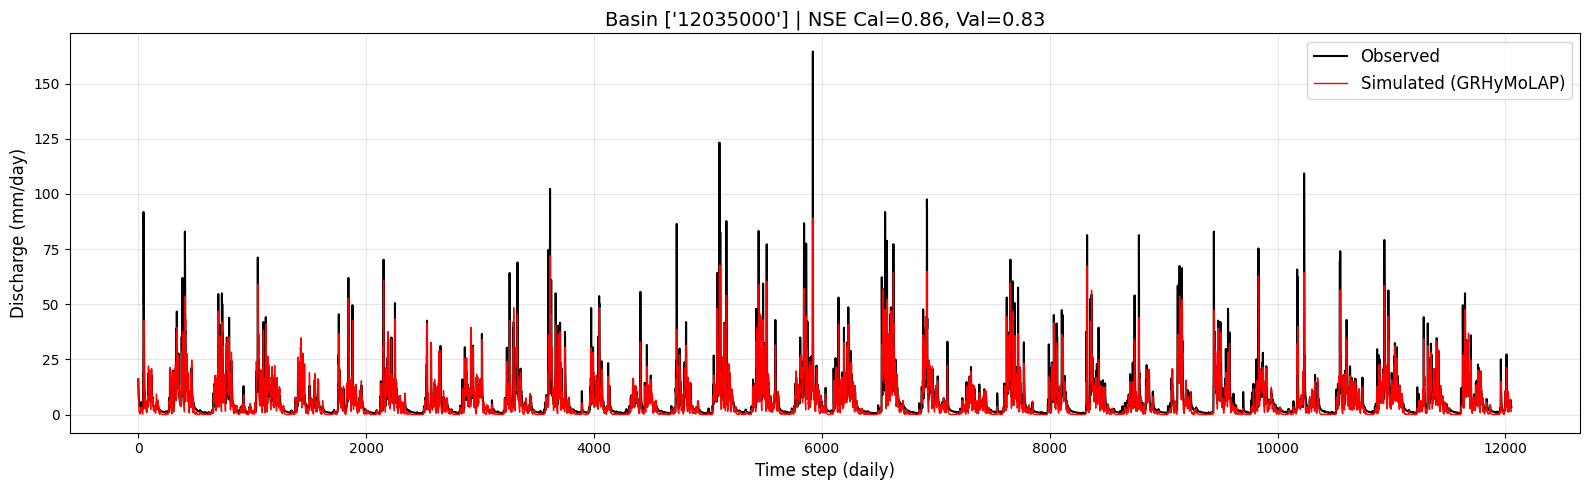

In [25]:
import matplotlib.pyplot as plt

# ===============================
# Identify the bassin 569
# ===============================
stations = list(results_GRHyMoLAP.keys())
station_569 = ['12035000']

res = results_GRHyMoLAP['12035000']
Q_obs = res["Q_obs"]
Qsim = res["Qsim"]

# ===============================
# Plot Observed vs Simulated
# ===============================
plt.figure(figsize=(16,5))
plt.plot(Q_obs, label="Observed", color="black", linewidth=1.5)
plt.plot(Qsim, label="Simulated (GRHyMoLAP)", color="red", linewidth=1.)

plt.title(f"Basin {station_569} | NSE Cal={res['NSE_cal']:.2f}, Val={res['NSE_val']:.2f}", fontsize=14)
plt.xlabel("Time step (daily)", fontsize=12)
plt.ylabel("Discharge (mm/day)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ============================================
# Create excel file with metrics
# ============================================

records = []
for station_id, res in results_GRHyMoLAP.items():
    record = {
        "Station": station_id,
        "NSE_val": res["NSE_val"],
        "NNSE_val": res["NNSE_val"],
        "RMSE_val": res["RMSE_val"],
        "PBIAS_val": res["PBIAS_val"],
        "FHV_val": res["FHV_val"],
        "FLV_val": res["FLV_val"],
    }
    records.append(record)

df_val_metrics = pd.DataFrame(records)
excel_filename = "GRHyMoLAP_validation_metrics.xlsx"
df_val_metrics.to_excel(excel_filename, index=False)
print(f"✅ Excel saved: {excel_filename}")

# Download
try:
    from google.colab import files
    #files.download(excel_filename)
except:
    print("⚠️ Not running in Colab. File saved locally.")

✅ Excel saved: GRHyMoLAP_validation_metrics.xlsx


#Show dates

In [21]:
# ============================================
# DATES (CAL / VAL) - direct execution
# ============================================

start_date = "1981-01-01"
end_date = "2013-12-31"

q_mm_per_day_recent = q_mm_per_day.sel(time=slice(start_date, end_date))
ds_recent = ds.sel(time=slice(start_date, end_date)).load()

dates = ds_recent.time.to_index()

# calibration / validation split
b1 = int(len(dates) * b1_ratio)

dates_cal = dates[:b1]
dates_val = dates[b1:]

print("=== CALIBRATION DATES ===")
print(dates_cal)

print("\n=== VALIDATION DATES ===")
print(dates_val)

=== CALIBRATION DATES ===
DatetimeIndex(['1981-01-01', '1981-01-02', '1981-01-03', '1981-01-04',
               '1981-01-05', '1981-01-06', '1981-01-07', '1981-01-08',
               '1981-01-09', '1981-01-10',
               ...
               '2004-01-28', '2004-01-29', '2004-01-30', '2004-01-31',
               '2004-02-01', '2004-02-02', '2004-02-03', '2004-02-04',
               '2004-02-05', '2004-02-06'],
              dtype='datetime64[ns]', name='time', length=8437, freq=None)

=== VALIDATION DATES ===
DatetimeIndex(['2004-02-07', '2004-02-08', '2004-02-09', '2004-02-10',
               '2004-02-11', '2004-02-12', '2004-02-13', '2004-02-14',
               '2004-02-15', '2004-02-16',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='time', length=3616, freq=None)
